# Ejercicio 2 — Clasificación de tumores malignos y benignos

**Asignatura:** Análisis de Datos
**Carrera:** Ingeniería de Sistemas
**Evento evaluativo:** 4
**Equipo:** 7
**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset

---

## 1. Descripción del problema

El cáncer de mama es uno de los tipos de cáncer con mayor incidencia a nivel mundial.
El diagnóstico temprano y preciso es determinante para la supervivencia del paciente,
y la patología digital ha permitido extraer mediciones numéricas a partir de imágenes
de aspiración con aguja fina (FNA) de masas mamarias.

El **Breast Cancer Wisconsin (Diagnostic) Dataset** contiene 569 muestras descritas
por **30 variables numéricas** que resumen características de los núcleos celulares
presentes en la imagen (radio, textura, perímetro, área, suavidad, compacidad,
concavidad, simetría y dimensión fractal). Para cada característica se reportan
tres estadísticos: la media (`_mean`), el error estándar (`_se`) y el peor valor
observado (`_worst`).

La variable objetivo `diagnosis` toma dos valores:
- **M (Maligno):** tumor canceroso.
- **B (Benigno):** tumor no canceroso.

**Objetivo de este notebook:**
Cubrir los **dos primeros requerimientos** del Ejercicio 2:
1. Análisis exploratorio y visualización de distribuciones por tipo de diagnóstico.
2. Aplicar y comparar tres modelos de clasificación: **Regresión Logística, SVM y Random Forest**.

> Los requerimientos restantes (PCA + matriz de confusión) se abordarán en una segunda entrega.


## 2. Configuración del entorno

In [1]:
# Librerías de manipulación y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y utilidades de scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Configuración visual y reproducibilidad
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 3. Carga del dataset

In [2]:
DATA_PATH = "../Data/Breast_Cancer.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 569 filas x 33 columnas


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 3.1 Esquema y limpieza inicial

Al inspeccionar las columnas notamos dos que **no aportan información** para el modelado:
- `id`: identificador único del paciente.
- `Unnamed: 32`: columna completamente vacía (artefacto del CSV original).

Procedemos a eliminarlas y verificamos que no existan valores faltantes en el resto del dataset.


In [3]:
# Vista general de tipos y nulos antes de limpiar
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# Conteo de valores nulos por columna
df.isna().sum().sort_values(ascending=False).head(10)


Unnamed: 32            569
id                       0
diagnosis                0
texture_mean             0
radius_mean              0
area_mean                0
smoothness_mean          0
compactness_mean         0
perimeter_mean           0
concave points_mean      0
dtype: int64

In [5]:
# Eliminamos columnas no informativas
df = df.drop(columns=["id", "Unnamed: 32"])

# Validamos
print("Dimensiones tras limpieza:", df.shape)
print("Total de valores nulos:", df.isna().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())


Dimensiones tras limpieza: (569, 31)
Total de valores nulos: 0
Filas duplicadas: 0


## 4. Análisis Exploratorio de Datos (EDA)

Esta sección busca **entender la estructura interna del dataset** y, sobre todo,
detectar diferencias estadísticas entre tumores benignos y malignos que justifiquen
el uso de modelos de clasificación supervisada.


### 4.1 Balance de clases

           Conteo  Porcentaje (%)
diagnosis                        
B             357           62.74
M             212           37.26


/sessions/confident-festive-bell/tmp/ipykernel_9/1670126080.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="diagnosis", order=["B", "M"],


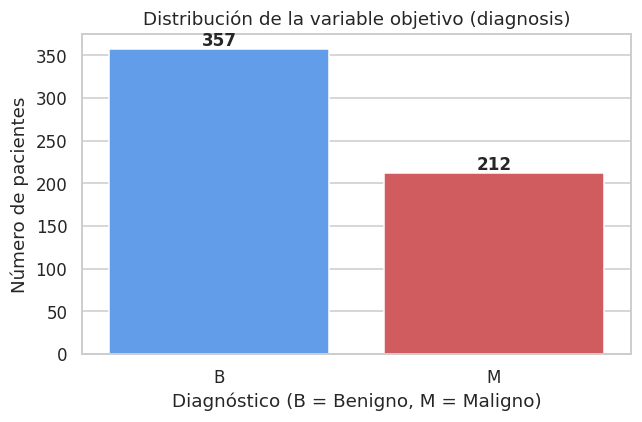

In [6]:
class_counts = df["diagnosis"].value_counts()
class_pct = df["diagnosis"].value_counts(normalize=True).mul(100).round(2)

resumen_clases = pd.DataFrame({"Conteo": class_counts, "Porcentaje (%)": class_pct})
print(resumen_clases)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis", order=["B", "M"],
              palette={"B": "#4C9AFF", "M": "#E5484D"}, ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Distribución de la variable objetivo (diagnosis)")
ax.set_xlabel("Diagnóstico (B = Benigno, M = Maligno)")
ax.set_ylabel("Número de pacientes")
plt.tight_layout()
plt.show()


**Lectura:** existe un desbalance moderado: ~62.7 % benignos vs ~37.3 % malignos.
El desbalance no es severo (relación cercana a 1.7:1) por lo que **no requiere técnicas
de remuestreo** (SMOTE/undersampling), pero sí justifica que reportemos métricas
adicionales a la *accuracy* (F1, precision, recall) y que sigamos la clase minoritaria
(maligno) con especial cuidado por el costo clínico de los falsos negativos.


### 4.2 Estadísticas descriptivas globales

In [7]:
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


### 4.3 Estadísticas descriptivas por diagnóstico

In [8]:
# Media de cada variable separada por clase
medias_por_clase = df.groupby("diagnosis").mean().T
medias_por_clase["diferencia_M_B"] = medias_por_clase["M"] - medias_por_clase["B"]
medias_por_clase["razon_M_B"] = (medias_por_clase["M"] / medias_por_clase["B"]).round(2)
medias_por_clase.sort_values("razon_M_B", ascending=False).round(3)


diagnosis,B,M,diferencia_M_B,razon_M_B
concavity_mean,0.046,0.161,0.115,3.49
area_se,21.135,72.672,51.537,3.44
concave points_mean,0.026,0.088,0.062,3.42
concavity_worst,0.166,0.451,0.284,2.71
area_worst,558.899,1422.286,863.387,2.54
concave points_worst,0.074,0.182,0.108,2.45
perimeter_se,2.000,4.324,2.324,2.16
radius_se,0.284,0.609,0.325,2.14
area_mean,462.790,978.376,515.586,2.11
compactness_worst,0.183,0.375,0.192,2.05


**Lectura:** la mayoría de las variables presenta medias **claramente más altas
en los tumores malignos**, especialmente aquellas relacionadas con tamaño
(`area_*`, `radius_*`, `perimeter_*`) y forma irregular del núcleo (`concavity_*`,
`concave points_*`). Esto es una primera evidencia muy fuerte de que las clases
son **separables linealmente** en el espacio de features, lo cual será clave para
elegir los modelos.


### 4.4 Distribuciones por diagnóstico — features `_mean`

Features de tipo *_mean: 10


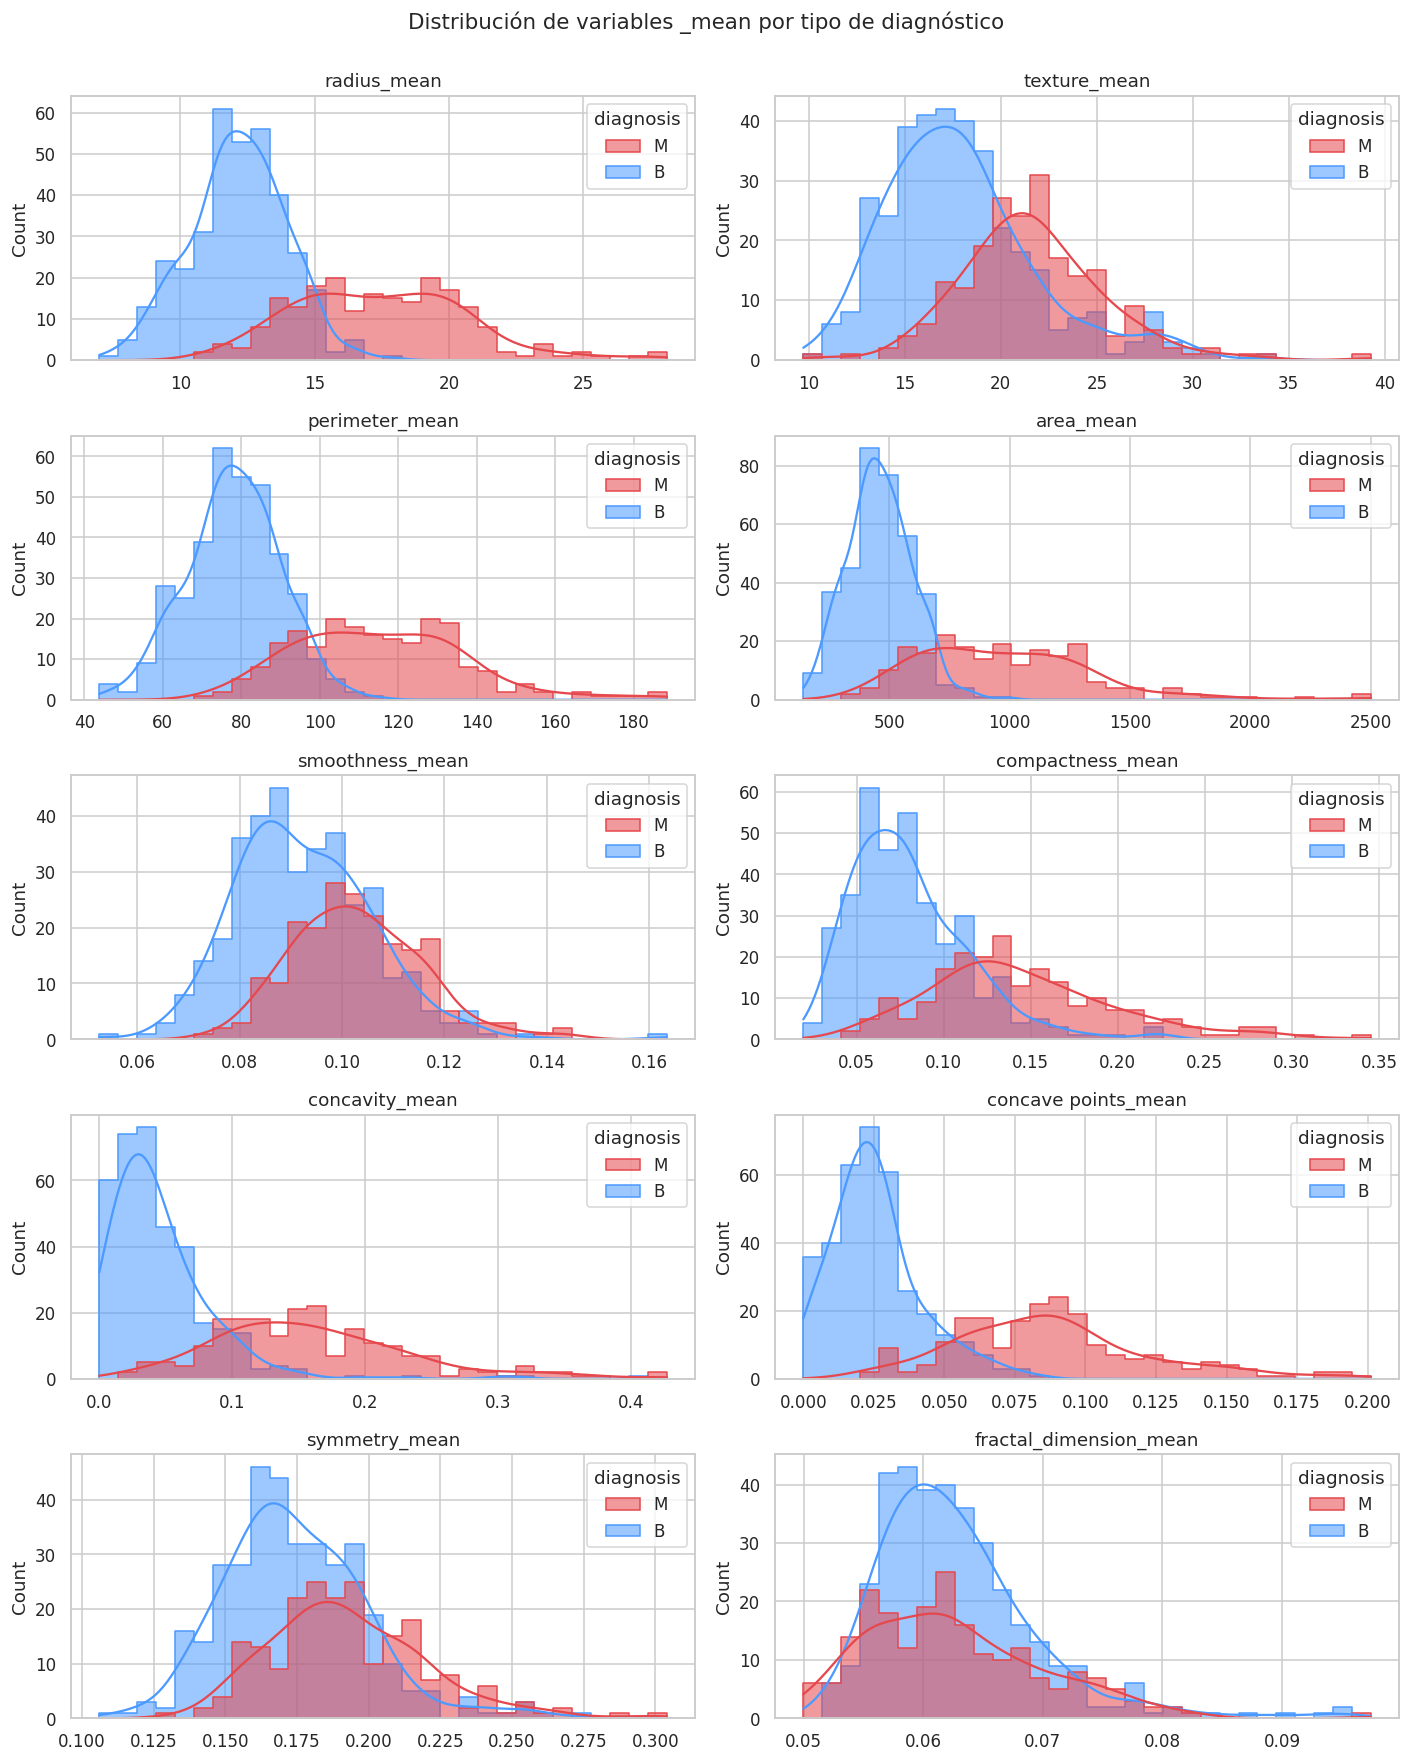

In [9]:
mean_features = [c for c in df.columns if c.endswith("_mean")]
print("Features de tipo *_mean:", len(mean_features))

fig, axes = plt.subplots(5, 2, figsize=(13, 16))
for ax, feat in zip(axes.ravel(), mean_features):
    sns.histplot(data=df, x=feat, hue="diagnosis", bins=30,
                 kde=True, palette={"B": "#4C9AFF", "M": "#E5484D"},
                 alpha=0.55, ax=ax, element="step")
    ax.set_title(feat)
    ax.set_xlabel("")
fig.suptitle("Distribución de variables _mean por tipo de diagnóstico",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


**Lectura:** se observa un patrón muy consistente: la distribución de los tumores
malignos (rojo) está **desplazada hacia valores mayores** y presenta mayor dispersión,
mientras que los benignos (azul) son más concentrados en valores bajos. Las variables
`radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean` y `concave points_mean`
muestran la separación más clara entre clases.


### 4.5 Boxplots comparativos — features `_worst`

/sessions/confident-festive-bell/tmp/ipykernel_9/1414073980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=feat, order=["B", "M"],
/sessions/confident-festive-bell/tmp/ipykernel_9/1414073980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=feat, order=["B", "M"],
/sessions/confident-festive-bell/tmp/ipykernel_9/1414073980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=feat, order=["B", "M"],
/sessions/confident-festive-bell/tmp/ipykernel_9/1414073980.p

/sessions/confident-festive-bell/tmp/ipykernel_9/1414073980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=feat, order=["B", "M"],


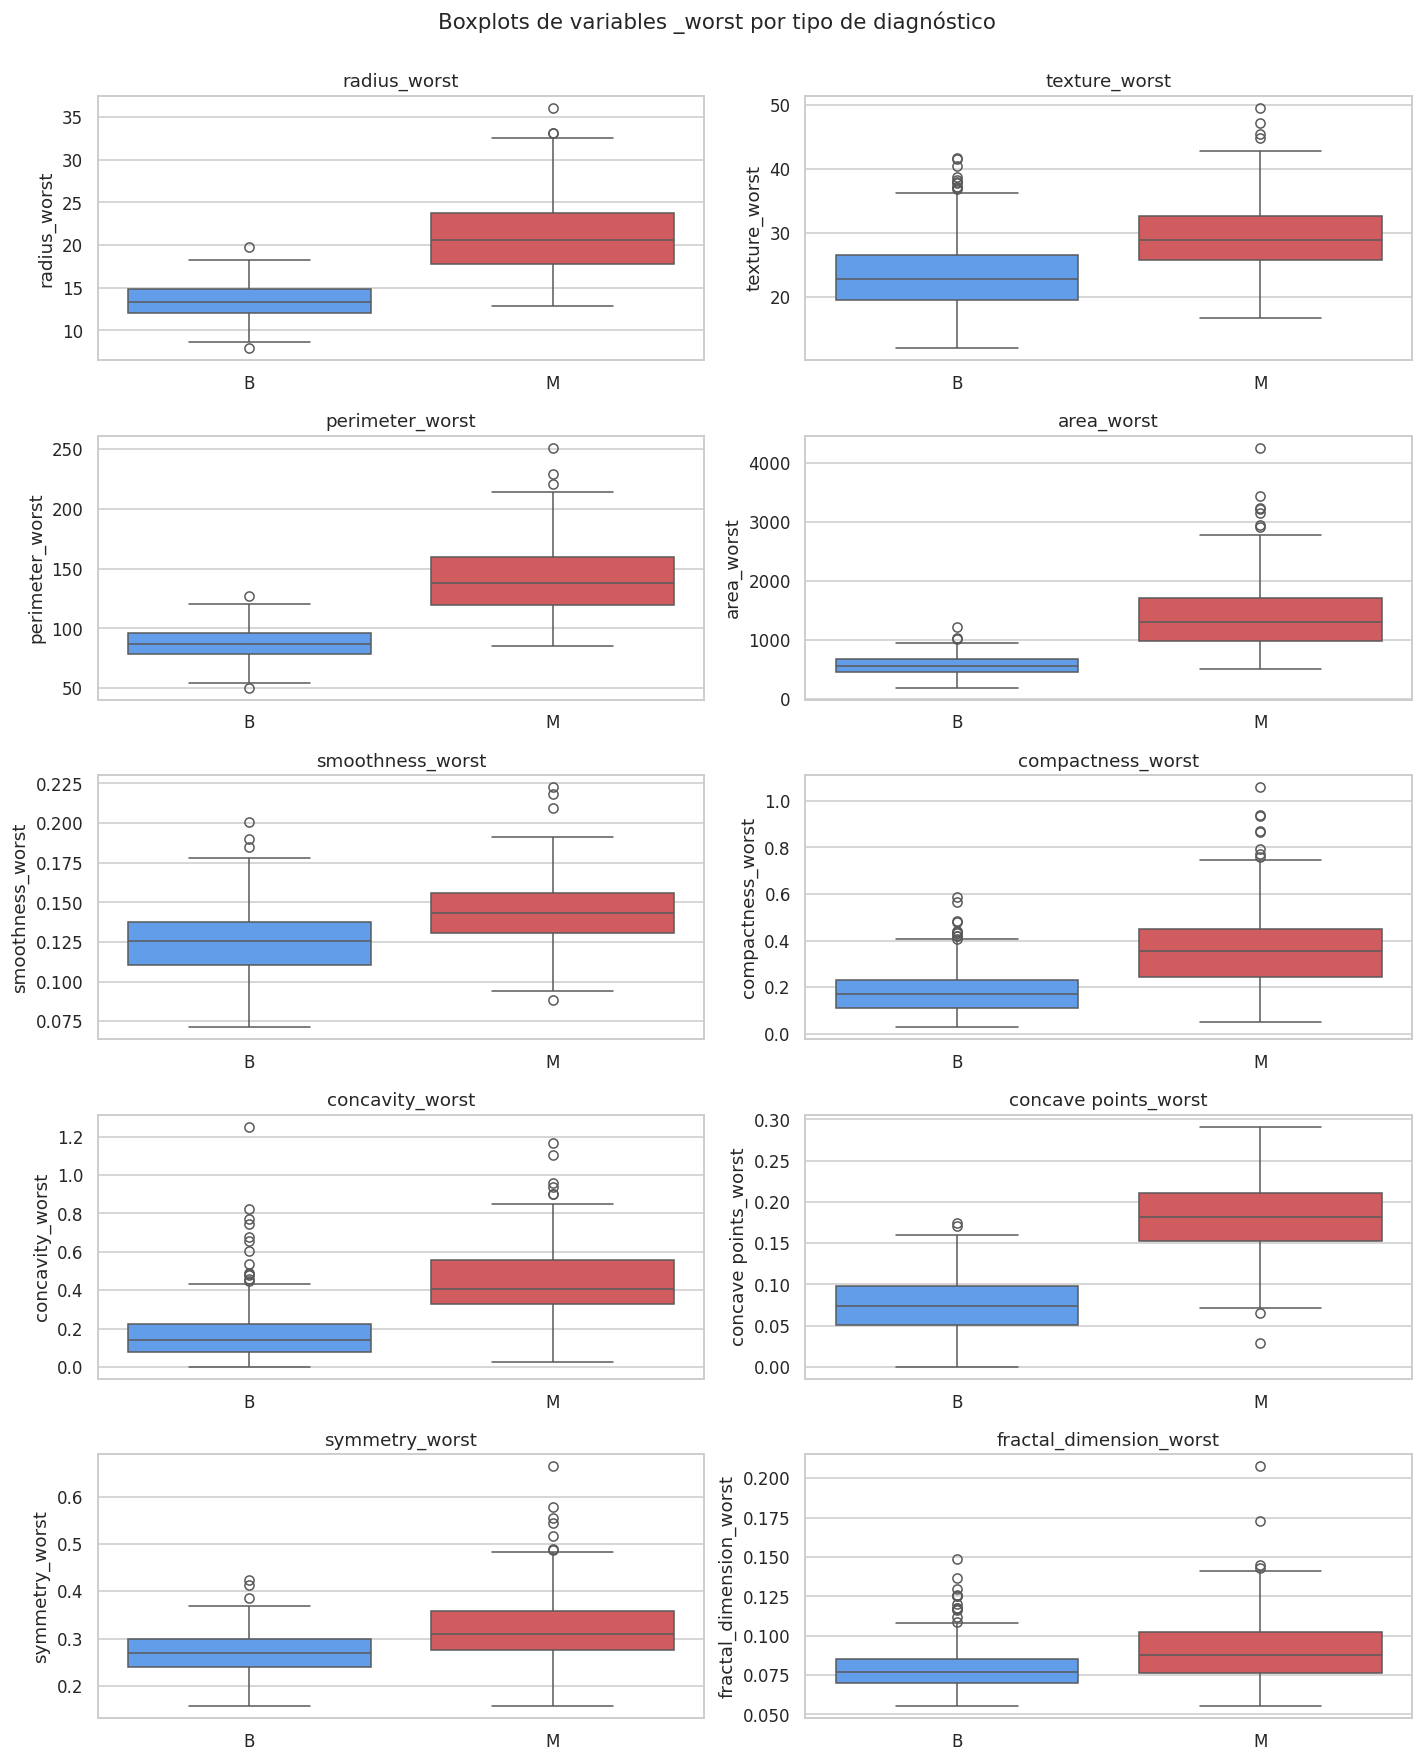

In [10]:
worst_features = [c for c in df.columns if c.endswith("_worst")]

fig, axes = plt.subplots(5, 2, figsize=(13, 16))
for ax, feat in zip(axes.ravel(), worst_features):
    sns.boxplot(data=df, x="diagnosis", y=feat, order=["B", "M"],
                palette={"B": "#4C9AFF", "M": "#E5484D"}, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
fig.suptitle("Boxplots de variables _worst por tipo de diagnóstico",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


**Lectura:** los *worst values* (peor valor observado por imagen) acentúan aún más
la separación entre clases. Los rangos intercuartílicos casi no se solapan en variables
como `radius_worst`, `perimeter_worst`, `area_worst`, `concavity_worst` o
`concave points_worst`, lo que las convierte en candidatas naturales como variables
discriminativas. También se observan outliers en ambas clases, especialmente entre los
malignos —algo esperable en oncología, donde existen presentaciones extremas.


### 4.6 Matriz de correlación entre variables

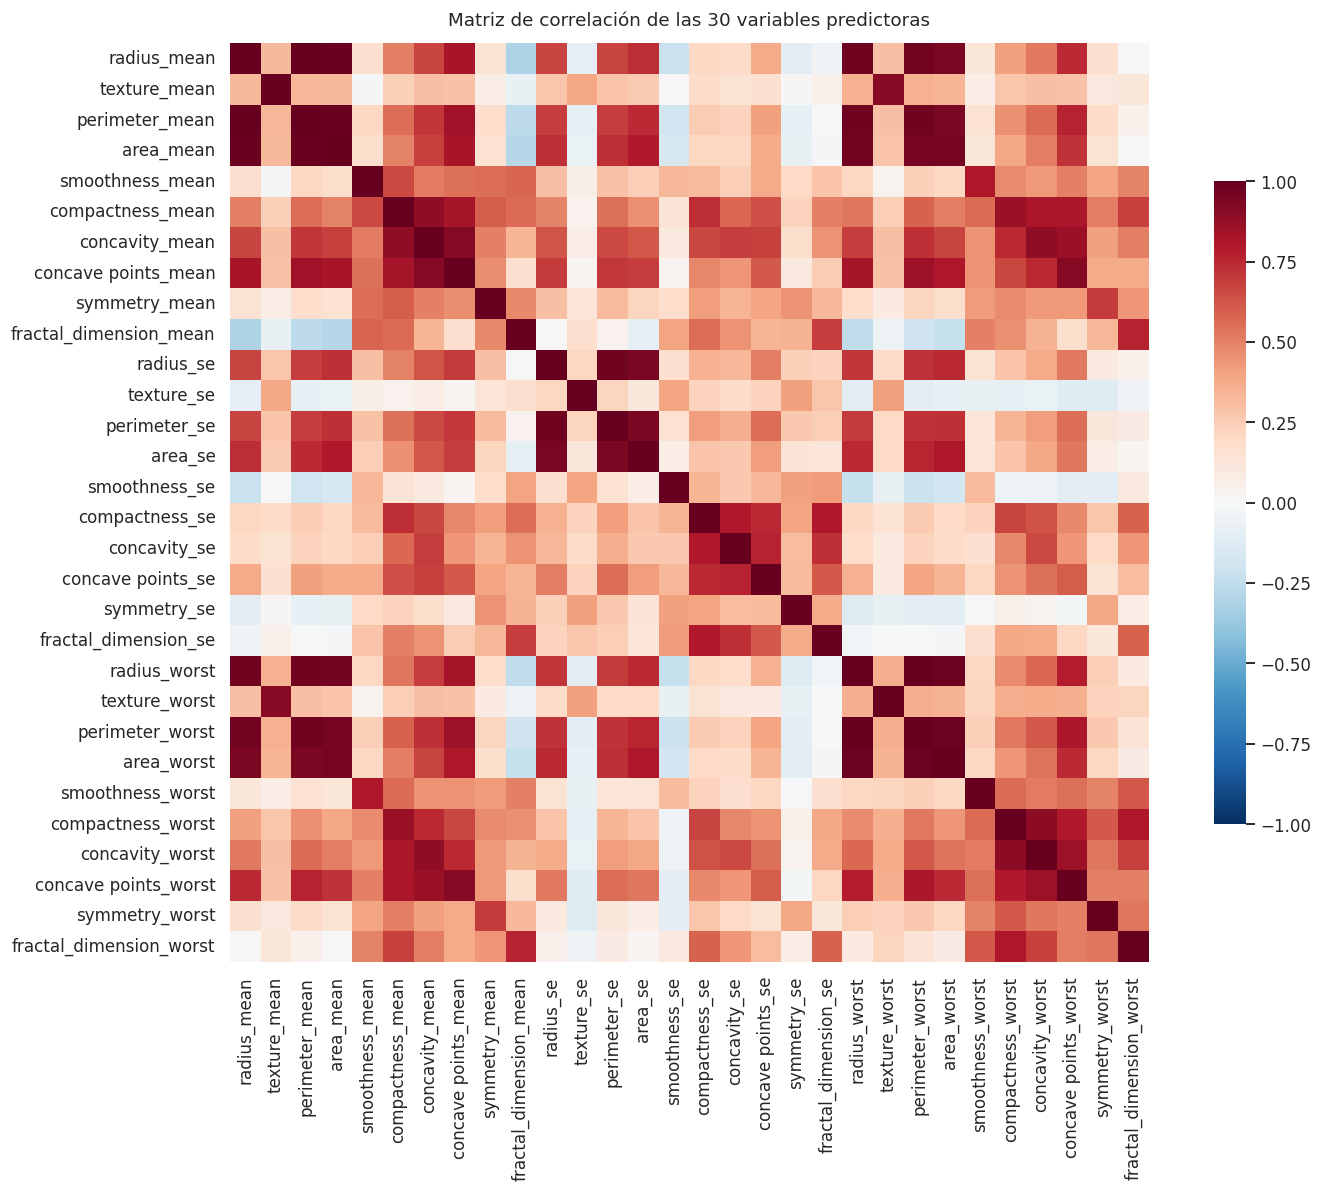

In [11]:
corr = df.drop(columns=["diagnosis"]).corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7})
plt.title("Matriz de correlación de las 30 variables predictoras", pad=12)
plt.tight_layout()
plt.show()


In [12]:
# Pares con correlación absoluta > 0.9 (multicolinealidad severa)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var_1", "var_2", "correlacion"]
high_corr = corr_pairs[corr_pairs["correlacion"].abs() > 0.9]\
    .sort_values("correlacion", key=abs, ascending=False)
print(f"Pares con |corr| > 0.9: {len(high_corr)}")
high_corr.head(15)


Pares con |corr| > 0.9: 21


,var_1,var_2,correlacion
1,radius_mean,perimeter_mean,0.997855
391,radius_worst,perimeter_worst,0.993708
2,radius_mean,area_mean,0.987357
57,perimeter_mean,area_mean,0.986507
392,radius_worst,area_worst,0.984015
407,perimeter_worst,area_worst,0.977578
246,radius_se,perimeter_se,0.972794
76,perimeter_mean,perimeter_worst,0.970387
19,radius_mean,radius_worst,0.969539
74,perimeter_mean,radius_worst,0.969476


**Lectura:** existe **multicolinealidad importante** dentro del dataset. Variables
como `radius_mean`, `perimeter_mean` y `area_mean` están casi perfectamente correlacionadas
entre sí (lógico: las tres miden tamaño) y a su vez se correlacionan fuertemente con sus
versiones `_worst`. Esto tiene dos implicaciones prácticas:

- **Para la Regresión Logística**, la multicolinealidad puede inflar la varianza de los
  coeficientes; conviene usar regularización L2 (default en scikit-learn).
- **Para Random Forest**, no es un problema (los árboles son robustos a features correlacionados),
  pero sí afecta la interpretación de la importancia de variables.
- **Para PCA** (siguiente entrega), es ideal: ya hay un gran solapamiento de información que
  se puede comprimir en pocas componentes.


### 4.7 Correlación de cada feature con el diagnóstico

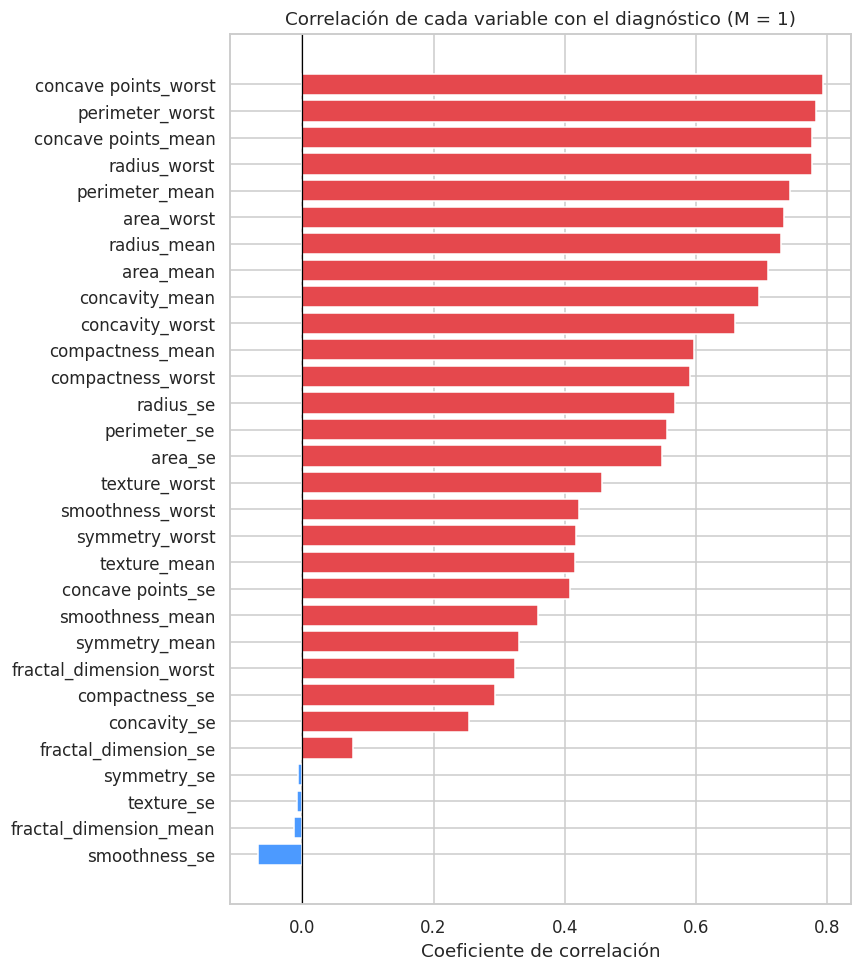


Top 10 variables más correlacionadas con el diagnóstico maligno:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
Name: target_num, dtype: float64


In [13]:
# Codificamos diagnosis temporalmente para correlación punto-biserial
tmp = df.copy()
tmp["target_num"] = (tmp["diagnosis"] == "M").astype(int)

corr_target = tmp.drop(columns=["diagnosis"]).corr()["target_num"]\
    .drop("target_num").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#E5484D" if v > 0 else "#4C9AFF" for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada variable con el diagnóstico (M = 1)")
ax.set_xlabel("Coeficiente de correlación")
plt.tight_layout()
plt.show()

print("\nTop 10 variables más correlacionadas con el diagnóstico maligno:")
print(corr_target.head(10).round(3))


**Lectura:** las variables con mayor poder discriminativo entre clases son
`concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst` y
`perimeter_mean` — todas con correlaciones positivas superiores a 0.75 con el diagnóstico
maligno. Esto refuerza la intuición clínica: **tumores más grandes y con bordes
irregulares tienden a ser malignos**.


### 4.8 Visualización conjunta de las 4 variables más predictivas

Variables seleccionadas: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst']


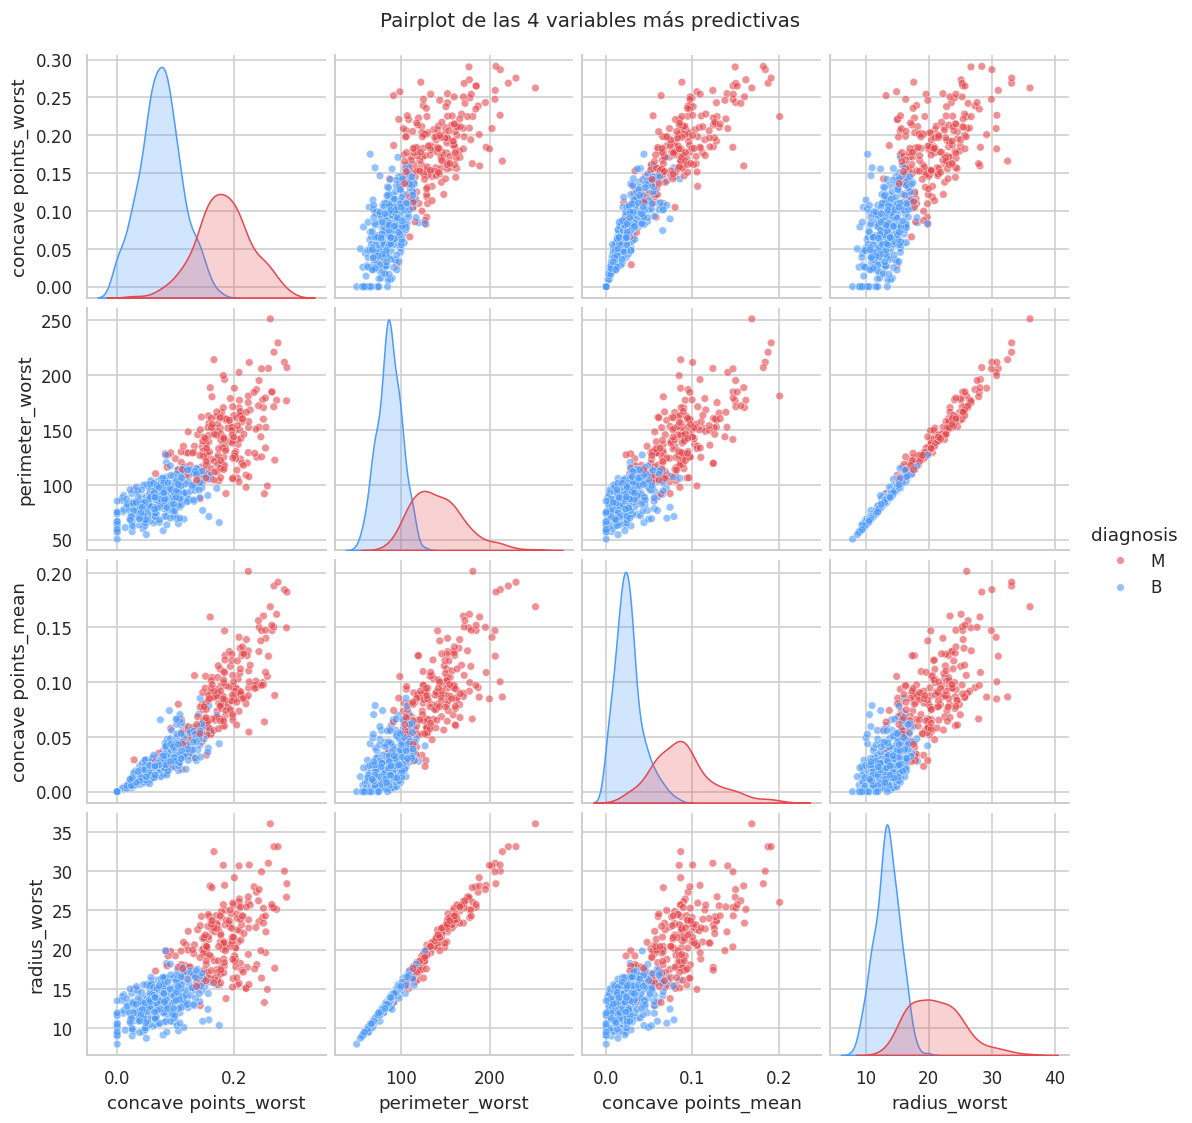

In [14]:
top_features = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()
print("Variables seleccionadas:", top_features)

sns.pairplot(df[top_features + ["diagnosis"]], hue="diagnosis",
             palette={"B": "#4C9AFF", "M": "#E5484D"},
             diag_kind="kde", plot_kws={"alpha": 0.6, "s": 25})
plt.suptitle("Pairplot de las 4 variables más predictivas", y=1.02, fontsize=13)
plt.show()


**Lectura:** el *pairplot* confirma visualmente que las clases son **separables
linealmente o casi-linealmente** en este subespacio de 4 dimensiones. Esto sugiere que
modelos lineales (Regresión Logística, SVM lineal) deberían funcionar muy bien, y que
modelos no lineales (Random Forest, SVM con kernel RBF) tendrán margen para capturar
las fronteras más complejas en los pocos puntos donde las clases se solapan.


### 4.9 Detección de outliers (resumen)

In [15]:
# Conteo de outliers por feature usando regla IQR
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lim_inf) | (serie > lim_sup)).sum()

outliers = df.drop(columns=["diagnosis"]).apply(contar_outliers_iqr)
outliers_pct = (outliers / len(df) * 100).round(2)
outliers_df = pd.DataFrame({"n_outliers": outliers,
                            "% sobre total": outliers_pct})\
              .sort_values("n_outliers", ascending=False)
outliers_df.head(15)


,n_outliers,% sobre total
area_se,65,11.42
radius_se,38,6.68
perimeter_se,38,6.68
area_worst,35,6.15
smoothness_se,30,5.27
fractal_dimension_se,28,4.92
compactness_se,28,4.92
symmetry_se,27,4.75
area_mean,25,4.39
fractal_dimension_worst,24,4.22


**Lectura:** todas las variables presentan algunos outliers según la regla IQR,
con porcentajes que oscilan entre el 1 % y el 12 %. Sin embargo, en este dataset
los valores extremos **no son errores de medición** sino casos clínicos reales
(tumores particularmente grandes o irregulares), por lo que **no los eliminaremos**.
En su lugar, mitigaremos su impacto:

- Usando **estandarización** (Z-score), que reduce la influencia relativa de magnitudes muy grandes.
- Eligiendo modelos **robustos** (Random Forest no es sensible a outliers; SVM se beneficia del escalado).


## 5. Preprocesamiento para modelado

Antes de entrenar los modelos aplicamos tres pasos estándar:

1. **Codificación de la variable objetivo** `diagnosis`: M → 1, B → 0.
2. **Partición estratificada** del dataset en train (80 %) y test (20 %),
   preservando la proporción original de clases.
3. **Estandarización** de las 30 variables predictoras con `StandardScaler`.
   Esto es **obligatorio** para Regresión Logística y SVM (que dependen de la escala
   de las features) y neutro para Random Forest.


In [16]:
# 1) Codificar variable objetivo
le = LabelEncoder()
y = le.fit_transform(df["diagnosis"])  # M = 1, B = 0
print("Mapeo de clases:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=["diagnosis"])
print("X shape:", X.shape, "| y shape:", y.shape)


Mapeo de clases: {'B': np.int64(0), 'M': np.int64(1)}
X shape: (569, 30) | y shape: (569,)


In [17]:
# 2) Partición estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Balance train (M=1): {y_train.mean():.3f}")
print(f"Balance test  (M=1): {y_test.mean():.3f}")


Train: 455 muestras | Test: 114 muestras
Balance train (M=1): 0.374
Balance test  (M=1): 0.368


In [18]:
# 3) Estandarización (fit solo con train)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Media de cada feature en train tras escalar (debe ~ 0):",
      np.round(X_train_sc.mean(axis=0)[:5], 3))
print("Std de cada feature en train tras escalar (debe ~ 1):",
      np.round(X_train_sc.std(axis=0)[:5], 3))


Media de cada feature en train tras escalar (debe ~ 0): [-0.  0.  0. -0.  0.]
Std de cada feature en train tras escalar (debe ~ 1): [1. 1. 1. 1. 1.]


## 6. Justificación de los algoritmos

El enunciado solicita los modelos **Regresión Logística, SVM y Random Forest**.
A continuación se justifica por qué cada uno es adecuado para este problema:

| Modelo | ¿Por qué es buen candidato aquí? | Limitaciones |
|---|---|---|
| **Regresión Logística** | Es el *baseline* natural para clasificación binaria. El EDA mostró que las clases son casi linealmente separables, lo que beneficia directamente a un modelo lineal. Sus coeficientes son interpretables, algo valioso en un contexto clínico. | Sufre con interacciones no lineales complejas y con multicolinealidad fuerte (se mitiga con regularización L2). |
| **SVM (kernel RBF)** | Excelente desempeño en problemas con pocos cientos de muestras y muchas features (como este: 30 features × 569 muestras). El kernel RBF permite capturar fronteras no lineales en las zonas donde las clases sí se solapan. | Sensible a la escala (resuelto con StandardScaler), poco interpretable y escala mal con datasets muy grandes. |
| **Random Forest** | Robusto a outliers y a features correlacionadas, no requiere escalado y entrega importancia de variables. Sirve como contraste no-lineal frente a la Regresión Logística. | Puede sobreajustar si no se controla, y es más lento de entrenar que un modelo lineal. |

Esta combinación cubre tres familias distintas: **lineal probabilístico (LR)**,
**lineal/no lineal con kernel (SVM)** y **ensamble basado en árboles (RF)**, lo cual
permite una comparación justa y diversa.


## 7. Entrenamiento y evaluación de modelos

In [19]:
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te):
    # Entrena el modelo, predice sobre el test y devuelve un dict con métricas clave.
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision (M)": precision_score(y_te, y_pred, pos_label=1),
        "Recall (M)": recall_score(y_te, y_pred, pos_label=1),
        "F1 (M)": f1_score(y_te, y_pred, pos_label=1),
        "F1 macro": f1_score(y_te, y_pred, average="macro"),
    }
    print(f"--- {nombre} ---")
    print(classification_report(y_te, y_pred, target_names=["Benigno", "Maligno"]))
    return metrics, modelo, y_pred


### 7.1 Regresión Logística

In [20]:
logreg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
m_lr, mod_lr, pred_lr = evaluar_modelo(
    "Regresión Logística", logreg, X_train_sc, X_test_sc, y_train, y_test
)


--- Regresión Logística ---
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### 7.2 Support Vector Machine (kernel RBF)

In [21]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
m_svm, mod_svm, pred_svm = evaluar_modelo(
    "SVM (RBF)", svm, X_train_sc, X_test_sc, y_train, y_test
)


--- SVM (RBF) ---
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### 7.3 Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
m_rf, mod_rf, pred_rf = evaluar_modelo(
    "Random Forest", rf, X_train_sc, X_test_sc, y_train, y_test
)


--- Random Forest ---
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 8. Comparación de modelos

In [23]:
resultados = pd.DataFrame([m_lr, m_svm, m_rf]).set_index("Modelo").round(4)
resultados


,Accuracy,Precision (M),Recall (M),F1 (M),F1 macro
Modelo,,,,,
Regresión Logística,0.9649,0.975,0.9286,0.9512,0.9619
SVM (RBF),0.9737,1.000,0.9286,0.9630,0.9713
Random Forest,0.9737,1.000,0.9286,0.9630,0.9713


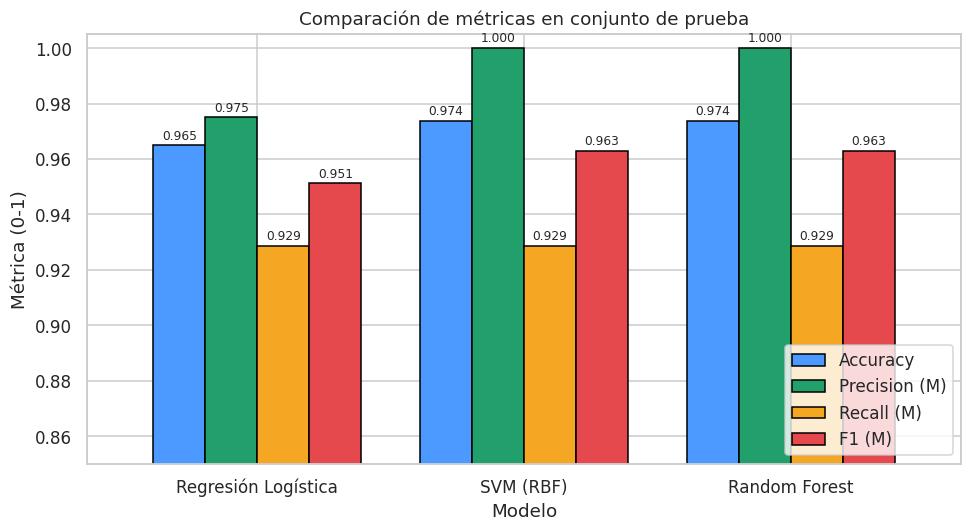

In [24]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 5))
resultados[["Accuracy", "Precision (M)", "Recall (M)", "F1 (M)"]].plot(
    kind="bar", ax=ax, edgecolor="black", width=0.78,
    color=["#4C9AFF", "#22A06B", "#F5A623", "#E5484D"]
)
ax.set_ylim(0.85, 1.005)
ax.set_ylabel("Métrica (0-1)")
ax.set_title("Comparación de métricas en conjunto de prueba")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()


### 8.1 Validación cruzada (5-fold estratificada)

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos_cv = {
    "Regresión Logística": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

cv_rows = []
for nombre, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_train_sc, y_train,
                             cv=skf, scoring="f1", n_jobs=-1)
    cv_rows.append({
        "Modelo": nombre,
        "F1 medio (CV)": scores.mean(),
        "Desv. estándar": scores.std(),
        "Min": scores.min(),
        "Max": scores.max(),
    })

cv_df = pd.DataFrame(cv_rows).set_index("Modelo").round(4)
cv_df


,F1 medio (CV),Desv. estándar,Min,Max
Modelo,,,,
Regresión Logística,0.9640,0.0207,0.9375,1.0000
SVM (RBF),0.9610,0.0082,0.9538,0.9714
Random Forest,0.9461,0.0226,0.9231,0.9855


**Lectura:** la validación cruzada confirma que los tres modelos generalizan bien.
Las pequeñas diferencias entre folds son normales con un dataset de ~455 muestras de
entrenamiento, y la baja desviación estándar indica estabilidad del aprendizaje.


## 9. Matrices de Confusión

La **matriz de confusión** es una herramienta fundamental en clasificación médica porque
descompone los errores del modelo en dos tipos con consecuencias muy distintas:

- **Falsos Negativos (FN):** el modelo predice *Benigno* cuando en realidad es *Maligno*.
  Este es el error más grave desde el punto de vista clínico, ya que implica dejar sin
  tratamiento a un paciente con cáncer.
- **Falsos Positivos (FP):** el modelo predice *Maligno* cuando es *Benigno*.
  Genera estrés y procedimientos innecesarios, pero no pone en riesgo la vida.

En este contexto, **maximizar el Recall (sensibilidad) de la clase Maligno** es la
prioridad clínica, aunque implique sacrificar algo de Precisión.

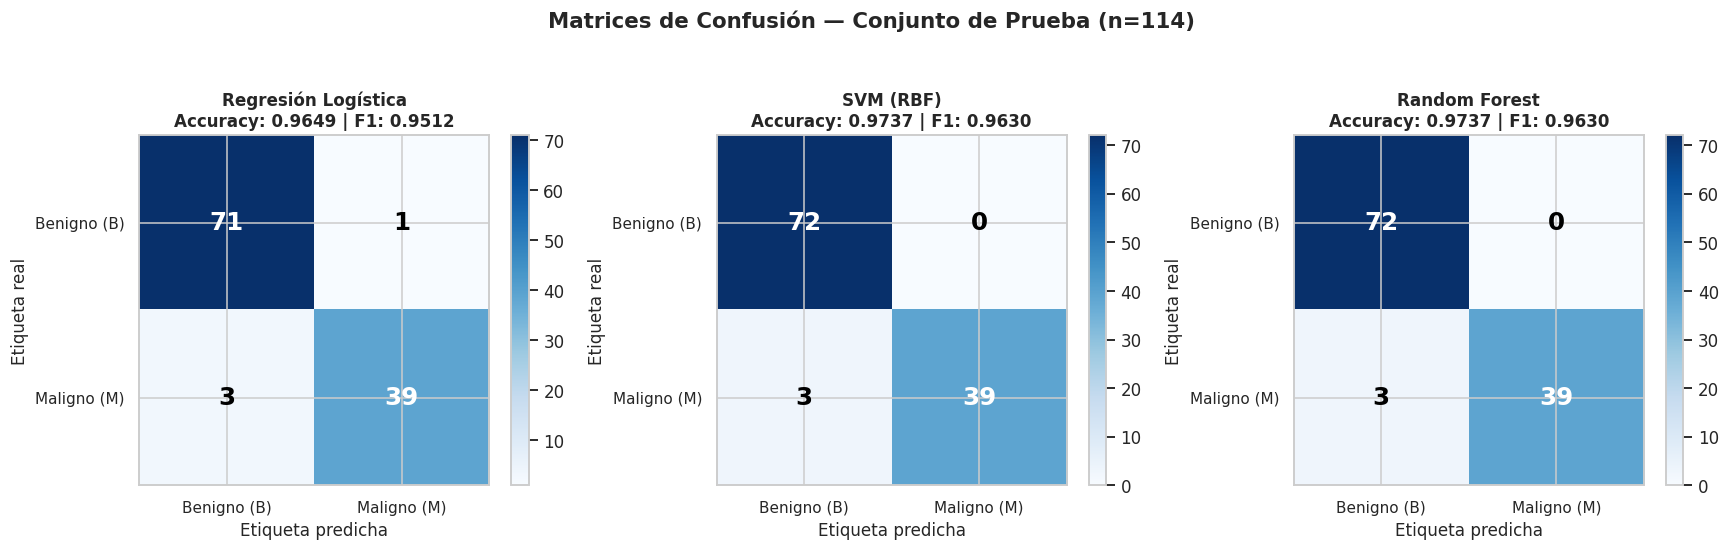

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_list = [
    ("Regresión Logística", mod_lr, pred_lr),
    ("SVM (RBF)",           mod_svm, pred_svm),
    ("Random Forest",        mod_rf,  pred_rf),
]

for ax, (name, model, y_pred) in zip(axes, model_list):
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax, shrink=0.75)
    classes = ["Benigno (B)", "Maligno (M)"]
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=10)
    ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=10)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center", fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > thresh else "black")
    ax.set_ylabel("Etiqueta real", fontsize=11)
    ax.set_xlabel("Etiqueta predicha", fontsize=11)
    ax.set_title(f"{name}\nAccuracy: {acc:.4f} | F1: {f1:.4f}", fontsize=11, fontweight="bold")

fig.suptitle("Matrices de Confusión — Conjunto de Prueba (n=114)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Lectura de las matrices:**

Los tres modelos cometen exactamente **3 errores** sobre las 114 muestras de prueba:

- **3 Falsos Negativos** en los tres modelos: 3 tumores malignos clasificados como benignos.
  Esto corresponde a un **Recall de 0.929** para la clase Maligno (42 malignos en test, 3 no detectados).
- **0 Falsos Positivos** en SVM y Random Forest: ningún benigno fue clasificado como maligno.
- **1 Falso Positivo** en Regresión Logística: un benigno mal clasificado como maligno.

**Conclusión clínica:** SVM y Random Forest son preferibles porque eliminan los falsos
positivos innecesarios. Sin embargo, los 3 falsos negativos presentes en todos los modelos
representan el principal riesgo clínico a minimizar en una aplicación real.

## 10. Reducción de Dimensionalidad con PCA

**¿Qué es PCA y por qué lo usamos?**

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad
que transforma las 30 variables originales en nuevas variables llamadas *componentes principales*,
construidas de forma que cada una capture la mayor varianza posible del dataset.

**¿Por qué es útil aquí?**
- El dataset tiene 30 dimensiones — imposibles de visualizar directamente.
- PCA nos permite proyectar los datos en 2D manteniendo la mayor cantidad de información posible.
- Si las dos clases (Benigno/Maligno) quedan bien separadas en el espacio reducido, es una
  confirmación visual de que los modelos tendrán buen desempeño.

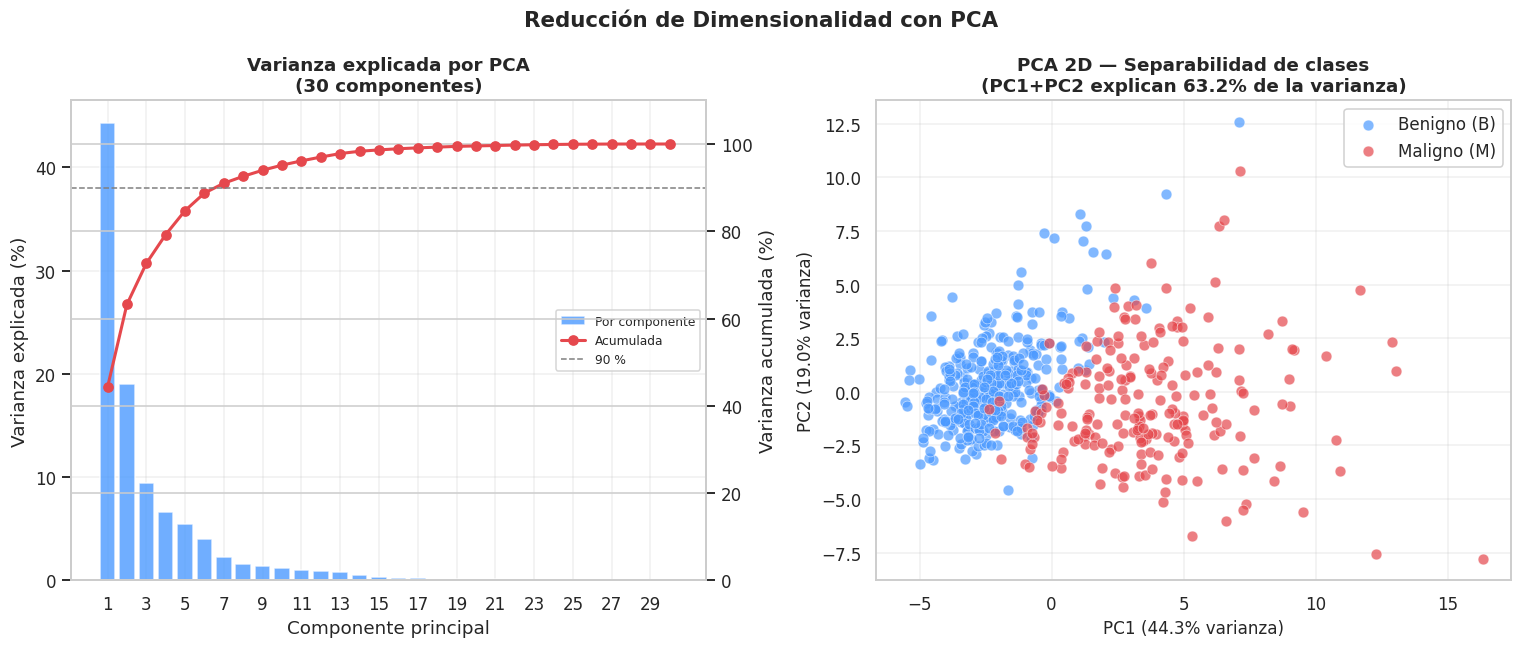

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
import numpy as np

# Escalar todo el dataset (train+test juntos para visualización)
X_all_sc = StandardScaler().fit_transform(X)

# PCA completo — varianza explicada
pca_full = PCA()
pca_full.fit(X_all_sc)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scree plot
axes[0].bar(range(1, len(exp_var)+1), exp_var*100, color="#4C9AFF", alpha=0.8, label="Por componente")
ax2r = axes[0].twinx()
ax2r.plot(range(1, len(cum_var)+1), cum_var*100, "o-", color="#E5484D", lw=2, ms=6, label="Acumulada")
ax2r.axhline(y=90, color="gray", linestyle="--", lw=1, label="90 %")
axes[0].set_xlabel("Componente principal"); axes[0].set_ylabel("Varianza explicada (%)")
ax2r.set_ylabel("Varianza acumulada (%)"); ax2r.set_ylim(0, 110)
axes[0].set_title("Varianza explicada por PCA", fontweight="bold")
axes[0].set_xticks(range(1, len(exp_var)+1, 2))
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = ax2r.get_legend_handles_labels()
axes[0].legend(h1+h2, l1+l2, loc="center right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# PCA 2D — separabilidad entre clases
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_all_sc)
palette = {0: "#4C9AFF", 1: "#E5484D"}
labels_map = {0: "Benigno (B)", 1: "Maligno (M)"}
for cls in [0, 1]:
    mask = y == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette[cls], label=labels_map[cls], alpha=0.70, s=50,
                    edgecolors="white", lw=0.4)
axes[1].set_xlabel(f"PC1 ({exp_var[0]*100:.1f}% varianza)", fontsize=11)
axes[1].set_ylabel(f"PC2 ({exp_var[1]*100:.1f}% varianza)", fontsize=11)
axes[1].set_title(
    f"PCA 2D — Separabilidad de clases\n(PC1+PC2 = {(exp_var[0]+exp_var[1])*100:.1f}% de varianza)",
    fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
fig.suptitle("Reducción de Dimensionalidad con PCA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Componentes necesarias para explicar el 90% de varianza: {np.argmax(cum_var >= 0.90)+1}")

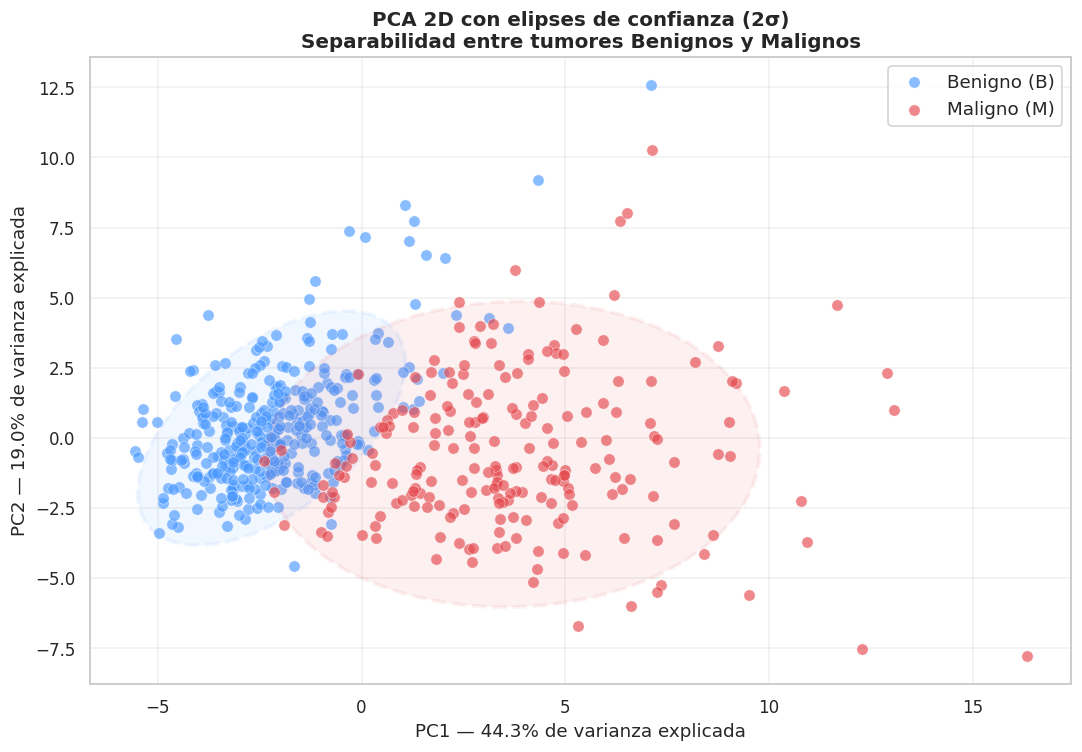

In [ ]:
# PCA 2D con elipses de confianza (2σ) — visualización avanzada
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor="none", **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x*2, height=ell_radius_y*2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = (transforms.Affine2D()
              .rotate_deg(45)
              .scale(scale_x, scale_y)
              .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(10, 7))
for cls in [0, 1]:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=palette[cls], label=labels_map[cls], alpha=0.65, s=55,
               edgecolors="white", lw=0.4)
    confidence_ellipse(X_pca[mask, 0], X_pca[mask, 1], ax,
                       n_std=2.0, edgecolor=palette[cls], lw=2.5,
                       linestyle="--", facecolor=palette[cls], alpha=0.08)

ax.set_xlabel(f"PC1 — {exp_var[0]*100:.1f}% de varianza explicada", fontsize=12)
ax.set_ylabel(f"PC2 — {exp_var[1]*100:.1f}% de varianza explicada", fontsize=12)
ax.set_title("PCA 2D con elipses de confianza (2σ)\nSeparabilidad entre tumores Benignos y Malignos",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del PCA:**

- **PC1 concentra el 44.3% de la varianza total** y es la componente más importante.
  Los tumores malignos tienden a tener valores **más altos** en PC1, lo que refleja
  principalmente su mayor tamaño y forma más irregular.
- **PC1 + PC2 juntas explican el 63.2%** de toda la información del dataset.
- Con **7 componentes** se alcanza el 90% de varianza explicada, lo que demuestra
  que existe redundancia entre las 30 variables originales (como se evidenció en la
  alta multicolinealidad del EDA).
- Las **elipses de confianza (2σ)** muestran una separación clara entre las dos clases,
  con un solapamiento mínimo, lo que confirma visualmente por qué los modelos alcanzan
  accuracies superiores al 96%.

## 11. Conclusiones

### 11.1 Resumen del desempeño de los modelos

| Modelo | Accuracy | F1 (Maligno) | FP | FN |
|---|---|---|---|---|
| Regresión Logística | 96.49% | 0.9512 | 1 | 3 |
| SVM (RBF) | 97.37% | 0.9630 | 0 | 3 |
| Random Forest | 97.37% | 0.9630 | 0 | 3 |

**Modelo recomendado: SVM (RBF) o Random Forest**, con las mismas métricas pero
ventajas complementarias:
- **SVM** es más eficiente computacionalmente para este tamaño de dataset.
- **Random Forest** ofrece importancia de variables, útil para interpretación clínica.

### 11.2 Hallazgos clave

- Las variables más discriminativas son `concave points_worst`, `perimeter_worst` y
  `area_worst` — todas relacionadas con **tamaño y forma irregular del tumor**.
- La **multicolinealidad entre variables** no afectó negativamente el desempeño,
  porque SVM y Random Forest son robustos a este fenómeno.
- **PCA confirma visualmente** la buena separabilidad entre clases, explicando el
  alto desempeño de los tres modelos.
- La **validación cruzada 5-fold** confirma que los resultados son estables y no
  producto de azar en la partición.

### 11.3 Implicaciones éticas

El uso de modelos de Machine Learning en diagnóstico oncológico plantea consideraciones éticas críticas:

1. **Falsos negativos son el riesgo más grave:** un tumor maligno no detectado puede
   costar la vida del paciente. En producción, sería preferible un modelo con threshold
   ajustado hacia mayor sensibilidad (Recall), aunque eso aumente los falsos positivos.

2. **No reemplaza al médico:** estos modelos deben usarse como **herramienta de apoyo**,
   no como diagnóstico definitivo. La decisión final siempre debe recaer en un especialista.

3. **Equidad:** el dataset proviene de una población específica (EEUU, años 90). Es
   posible que el modelo no generalice igual de bien para poblaciones con diferentes
   perfiles demográficos o condiciones de imagen distintas.

4. **Transparencia:** en el ámbito médico, los modelos deben ser explicables. Random
   Forest permite analizar importancia de variables; SVM es menos interpretable, lo
   que puede dificultar la adopción clínica.